# Pilot Test: Apple Watch Sensor Data for Exercise Classification

This notebook performs a pilot test by creating label-based visualizations of Apple Watch sensor data collected at **50 Hz** from the **SensorLog** app. The goal is to determine whether this data will be useful for building a classifier model that predicts exercise class labels from activity data.

**Class label mappings:**
| Label | Activity |
|-------|----------|
| 0 | Rest (standing) |
| 1 | Pull-up |
| 2 | Dips |
| 3 | Bicep curl |

We visualize the accelerometer signals (X, Y, Z) for each class to see if the activities produce distinguishable motion patterns.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE_RATE_HZ = 50

df = pd.read_csv('../data/stream_Apple_Watch_sample.csv')

accel_cols = [
    'accelerometerAccelerationX(G)',
    'accelerometerAccelerationY(G)',
    'accelerometerAccelerationZ(G)'
]

label_names = {0: 'Rest (standing)', 1: 'Pull-up', 2: 'Dips', 3: 'Bicep curl'}

print(f'Total samples: {len(df)}')
print(f'Sampling rate: {SAMPLE_RATE_HZ} Hz')
print(f'\nSamples per label:')
for label, name in label_names.items():
    count = (df['label'] == label).sum()
    duration = count / SAMPLE_RATE_HZ
    print(f'  {label} ({name}): {count} samples ({duration:.1f}s)')

Total samples: 3823
Sampling rate: 50 Hz

Samples per label:
  0 (Rest (standing)): 1610 samples (32.2s)
  1 (Pull-up): 759 samples (15.2s)
  2 (Dips): 499 samples (10.0s)
  3 (Bicep curl): 955 samples (19.1s)


## Label 0: Rest (standing)

There are multiple rest segments throughout the recording (between exercise bouts). We plot them all to see the baseline sensor readings when the subject is standing still.

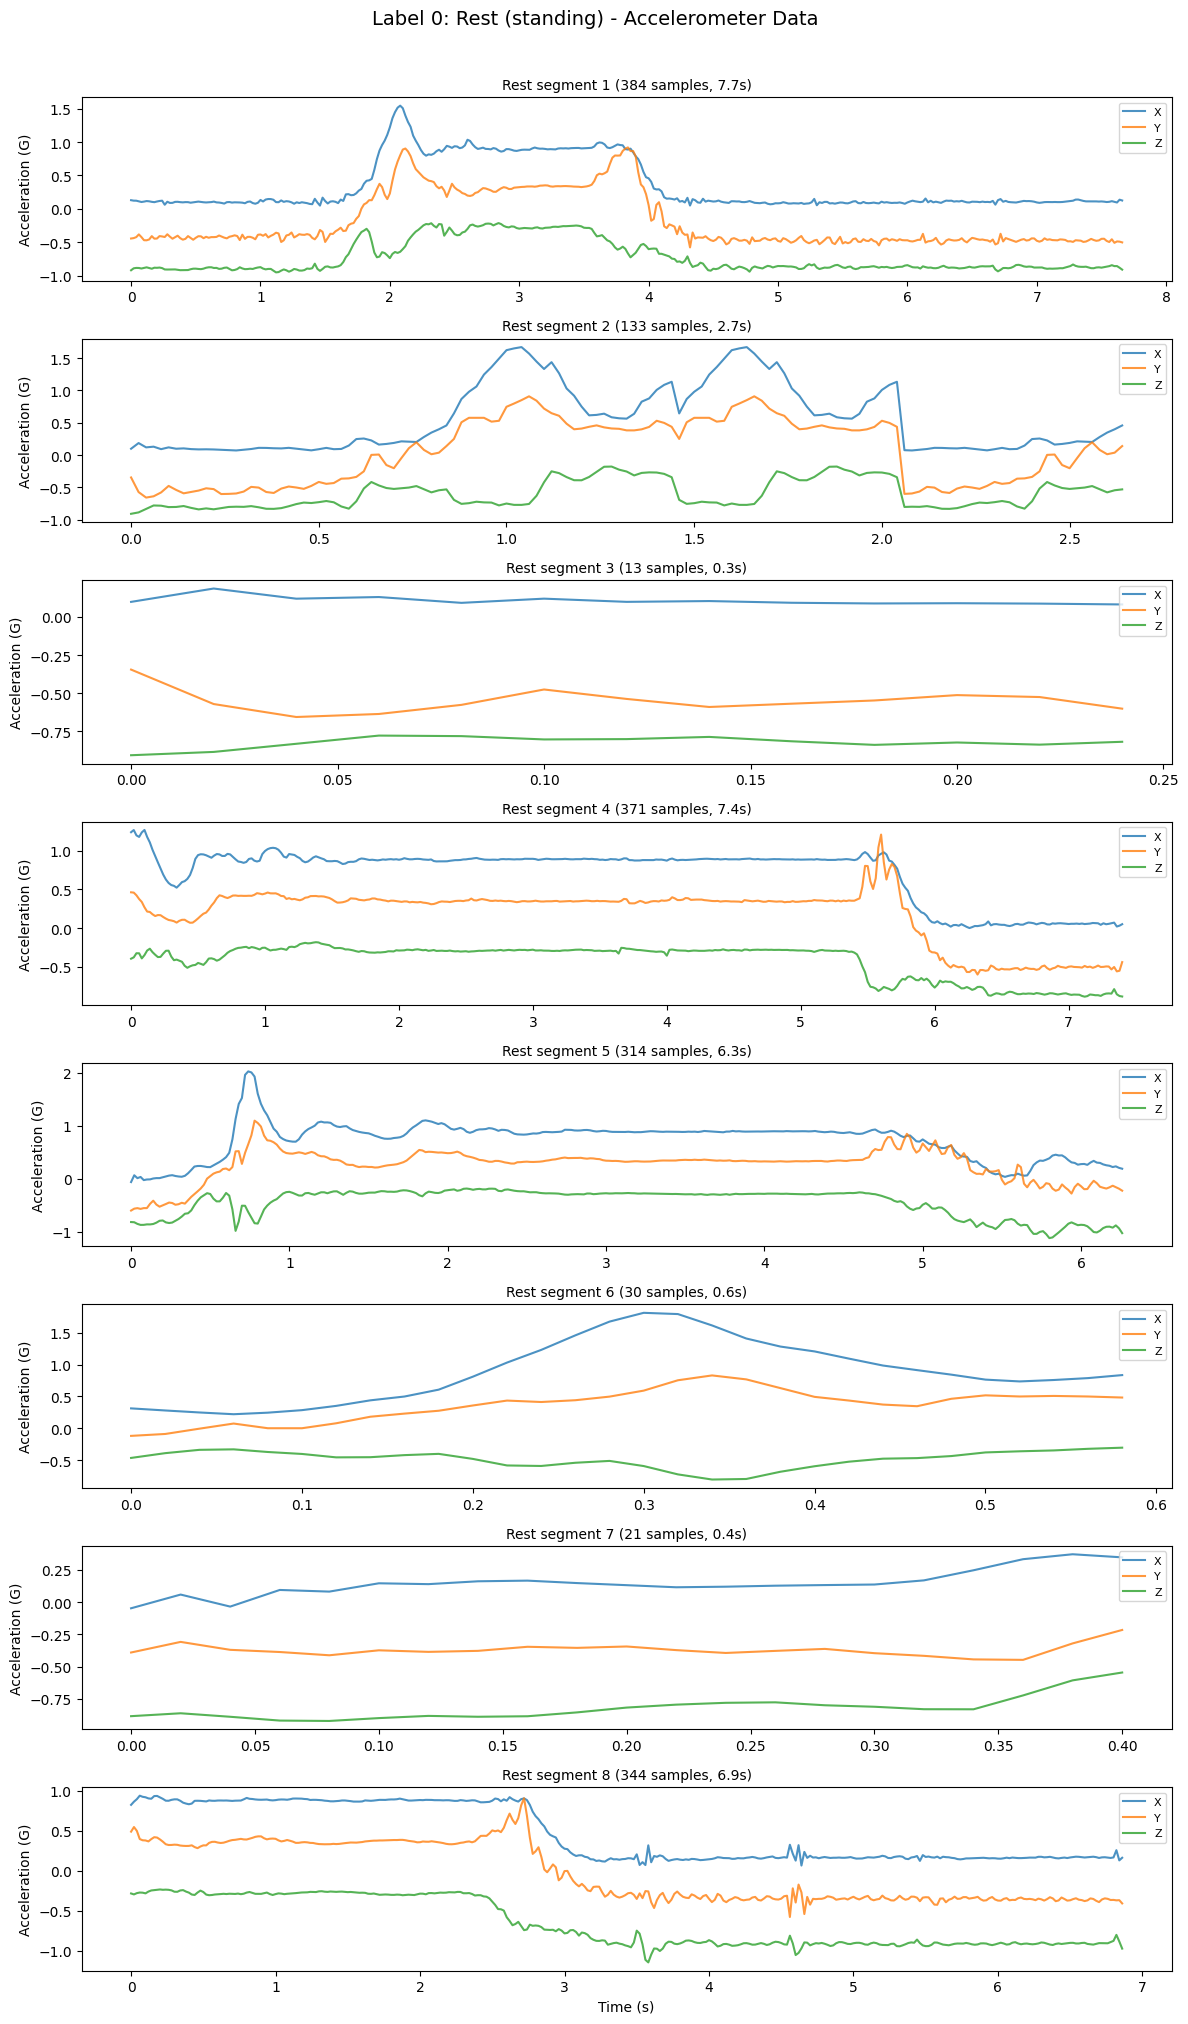

In [3]:
rest_data = df[df['label'] == 0].copy()

# Identify contiguous segments of rest
rest_data['segment'] = (rest_data.index.to_series().diff() > 1).cumsum()
n_segments = rest_data['segment'].nunique()

fig, axes = plt.subplots(n_segments, 1, figsize=(12, 2.5 * n_segments), squeeze=False)
fig.suptitle('Label 0: Rest (standing) - Accelerometer Data', fontsize=14, y=1.01)

for i, (seg_id, seg_data) in enumerate(rest_data.groupby('segment')):
    ax = axes[i, 0]
    time_s = [j / SAMPLE_RATE_HZ for j in range(len(seg_data))]
    ax.plot(time_s, seg_data[accel_cols[0]].values, label='X', alpha=0.8)
    ax.plot(time_s, seg_data[accel_cols[1]].values, label='Y', alpha=0.8)
    ax.plot(time_s, seg_data[accel_cols[2]].values, label='Z', alpha=0.8)
    ax.set_ylabel('Acceleration (G)')
    duration = len(seg_data) / SAMPLE_RATE_HZ
    ax.set_title(f'Rest segment {i+1} ({len(seg_data)} samples, {duration:.1f}s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Label 1: Pull-up

The pull-up data should show a repeating pattern of upward and downward motion as the subject pulls themselves up and lowers back down.

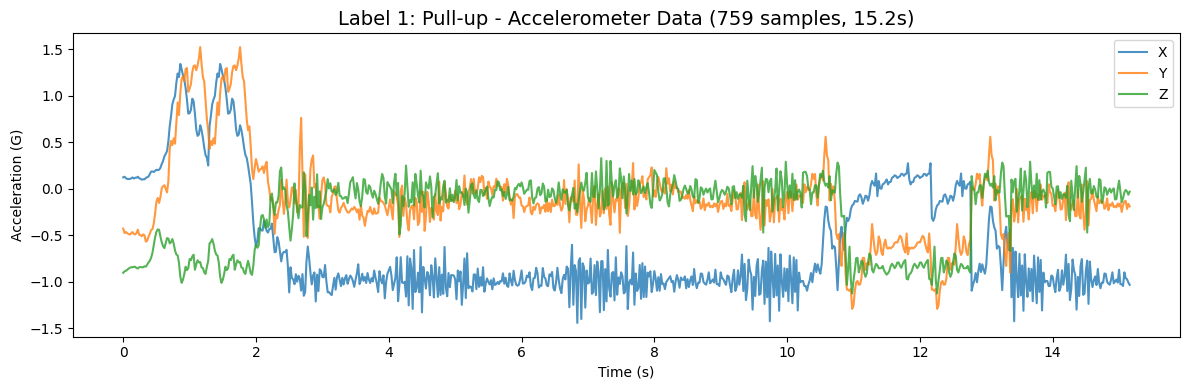

In [4]:
pullup_data = df[df['label'] == 1]
duration = len(pullup_data) / SAMPLE_RATE_HZ

fig, ax = plt.subplots(figsize=(12, 4))
time_s = [i / SAMPLE_RATE_HZ for i in range(len(pullup_data))]
ax.plot(time_s, pullup_data[accel_cols[0]].values, label='X', alpha=0.8)
ax.plot(time_s, pullup_data[accel_cols[1]].values, label='Y', alpha=0.8)
ax.plot(time_s, pullup_data[accel_cols[2]].values, label='Z', alpha=0.8)
ax.set_title(f'Label 1: Pull-up - Accelerometer Data ({len(pullup_data)} samples, {duration:.1f}s)', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (G)')
ax.legend()
plt.tight_layout()
plt.show()

## Label 2: Dips

The dips data should show a repeating pattern as the subject lowers and raises their body on parallel bars or a bench.

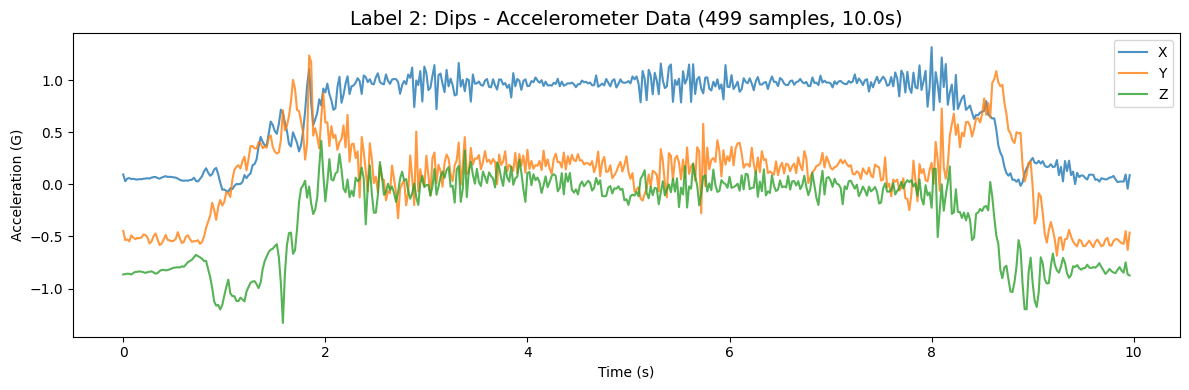

In [5]:
dips_data = df[df['label'] == 2]
duration = len(dips_data) / SAMPLE_RATE_HZ

fig, ax = plt.subplots(figsize=(12, 4))
time_s = [i / SAMPLE_RATE_HZ for i in range(len(dips_data))]
ax.plot(time_s, dips_data[accel_cols[0]].values, label='X', alpha=0.8)
ax.plot(time_s, dips_data[accel_cols[1]].values, label='Y', alpha=0.8)
ax.plot(time_s, dips_data[accel_cols[2]].values, label='Z', alpha=0.8)
ax.set_title(f'Label 2: Dips - Accelerometer Data ({len(dips_data)} samples, {duration:.1f}s)', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (G)')
ax.legend()
plt.tight_layout()
plt.show()

## Label 3: Bicep curl

The bicep curl data should show a repeating flexion/extension pattern as the subject curls and lowers a weight.

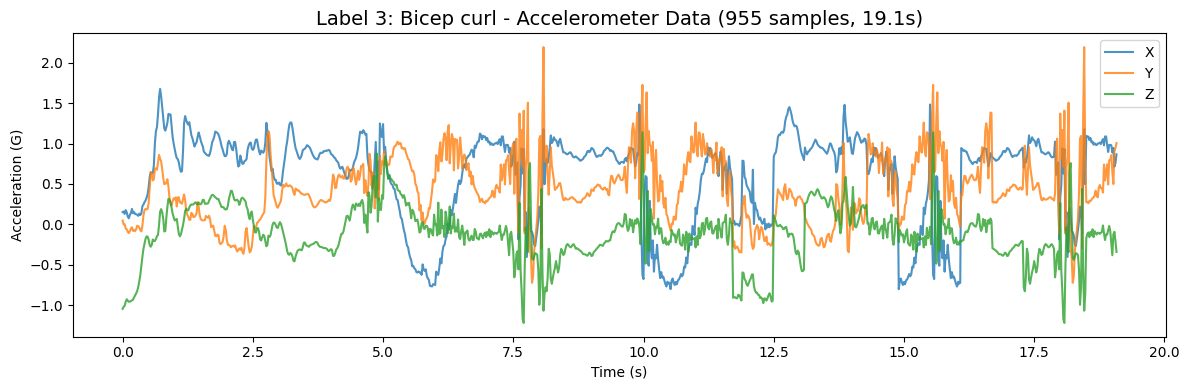

In [6]:
curl_data = df[df['label'] == 3]
duration = len(curl_data) / SAMPLE_RATE_HZ

fig, ax = plt.subplots(figsize=(12, 4))
time_s = [i / SAMPLE_RATE_HZ for i in range(len(curl_data))]
ax.plot(time_s, curl_data[accel_cols[0]].values, label='X', alpha=0.8)
ax.plot(time_s, curl_data[accel_cols[1]].values, label='Y', alpha=0.8)
ax.plot(time_s, curl_data[accel_cols[2]].values, label='Z', alpha=0.8)
ax.set_title(f'Label 3: Bicep curl - Accelerometer Data ({len(curl_data)} samples, {duration:.1f}s)', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (G)')
ax.legend()
plt.tight_layout()
plt.show()